In [89]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

path='/content/drive/MyDrive/Colab Notebooks/wine.csv'
df = pd.read_csv(path)

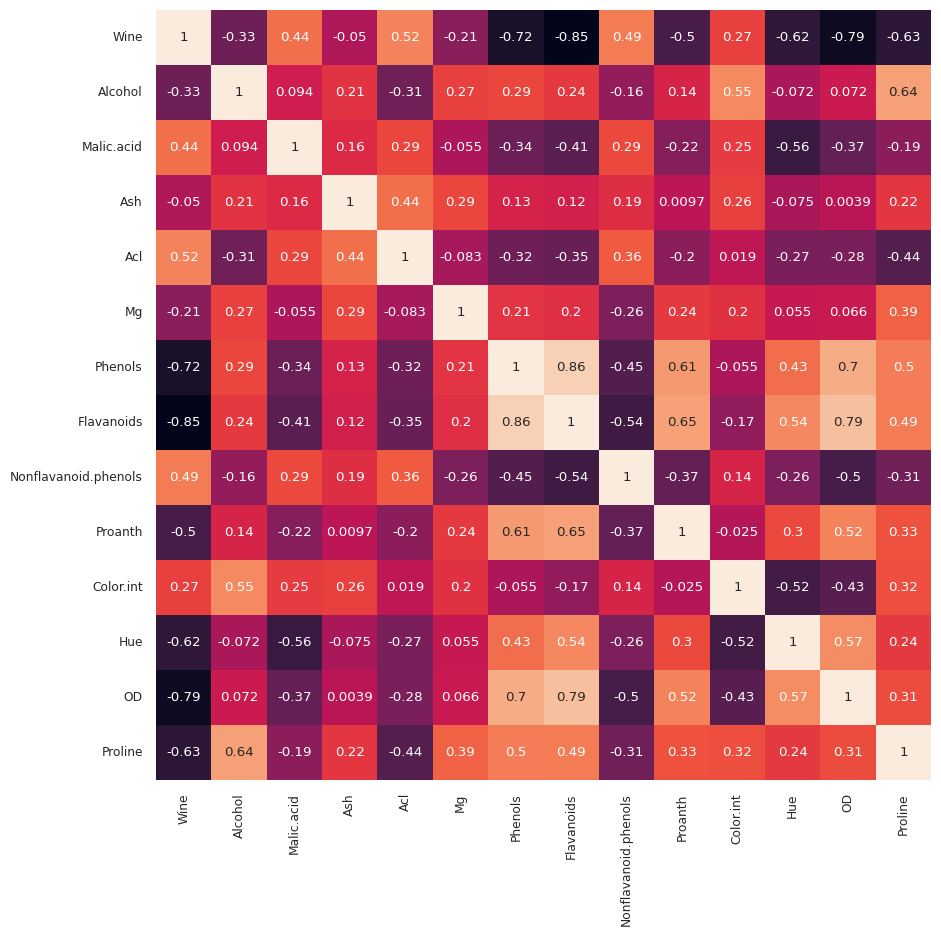

In [90]:
df_corr=df.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

In [91]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X=df.drop('Alcohol',axis=1)
X.head()


,Wine,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [92]:
y = df['Alcohol']
Y = y.values

In [93]:
X = pd.get_dummies(df.drop('Alcohol', axis=1), columns=['Wine'], dtype=int)
X = X.values
print(X.shape)


(178, 15)


In [94]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# 1. fit_transform: 훈련 데이터의 평균과 표준편차를 '계산(fit)'하고 바로 '변환(transform)'합니다. 모든 데이터를 평균을 0 표준편차는 1로 변신
X_train = scaler.fit_transform(X_train)

# 2. transform: 중요! 훈련 데이터에서 구한 '그 기준 그대로' 테스트 데이터도 변환합니다.
# (테스트 데이터로 새로 계산하면 안 돼요. 시험 문제는 공부한 기준대로 풀어야 하니까요!)
X_test = scaler.transform(X_test)

X_train.shape, y_train.shape, X_test.shape, y_test.shape,

((142, 15), (142,), (36, 15), (36,))

In [95]:
#Defining the model

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam


model = Sequential()

#입력 컬럼이 15갱임
model.add(Dense(8,input_shape=(15,),activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(1))
#결과가 1개이므로 마지막은 1로 끝남

model.compile(optimizer = 'rmsprop', loss = 'mse', metrics = ['mse'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 8)              │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,359 (5.31 KB)

 Trainable params: 1,359 (5.31 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
N_EPOCHS = 30

history=model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 165.0786 - mse: 165.0786 - val_loss: 162.2383 - val_mse: 162.2383
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 157.5222 - mse: 157.5222 - val_loss: 156.0396 - val_mse: 156.0396
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 151.3022 - mse: 151.3022 - val_loss: 149.9678 - val_mse: 149.9678
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 145.0903 - mse: 145.0903 - val_loss: 143.5869 - val_mse: 143.5869
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 138.4917 - mse: 138.4917 - val_loss: 137.0126 - val_mse: 137.0126
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 131.6578 - mse: 131.6578 - val_loss: 129.9420 - val_mse: 129.9420
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 124.3545 - mse: 124.3545 - val_loss: 122.2926 - val_mse: 122.2926
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 116.5351 - mse: 116.5351 - val_loss: 114.0517 - val_mse: 114.0517
Epoch 9/30
5/5 ━

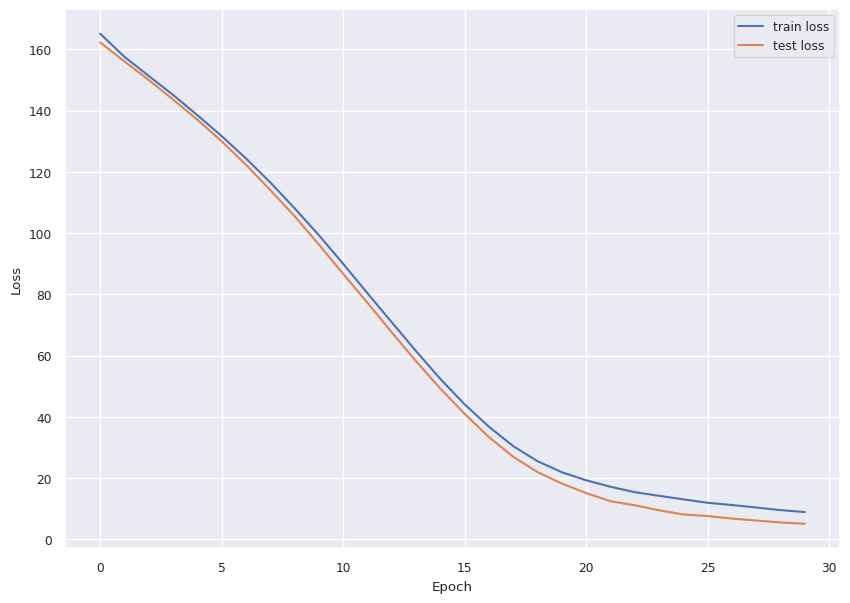

In [98]:
# loss 체크
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [99]:
model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 5.0987 - mse: 5.0987


[5.0986738204956055, 5.0986738204956055]